In [5]:
from cns.process.binning import *
from cns.process.breakpoints import *
from cns.process.segments import *
from cns.analyze.genome import *
from cns.utils.selection import cns_head
from cns.data_utils import load_cns_out, pjoin, out_path, data_path

# auto reload modules
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
cns_df, _ = load_cns_out("PCAWG_cns_imp.tsv")
cns_df = cns_head(cns_df, 20)
cns_df.head()

,chrom,start,end,major_cn,minor_cn
sample_id,,,,,
SP1003,chr1,0,37828027,2,2
SP1003,chr1,37828027,38563006,2,1
SP1003,chr1,38563006,39884821,2,0
SP1003,chr1,39884821,40536570,16,14
SP1003,chr1,40536570,104039773,2,1


In [14]:
cns_df["sample_id"].unique()

Index(['SP1003', 'SP10084', 'SP1009', 'SP10150', 'SP101515', 'SP101519',
       'SP101521', 'SP101523', 'SP101526', 'SP101528', 'SP101532', 'SP101536',
       'SP101540', 'SP101544', 'SP101548', 'SP101552', 'SP101558', 'SP101564',
       'SP101572', 'SP101576'],
      dtype='object', name='sample_id')

In [13]:
genes = pd.read_csv(pjoin(data_path, "COSMIC_consensus_genes.tsv"), sep="\t")
genes.head()

,gene,chrom,start,end
0,SKI,chr1,2160134,2241558
1,TNFRSF14,chr1,2487078,2496821
2,PRDM16,chr1,2985732,3355185
3,RPL22,chr1,6241329,6269449
4,CAMTA1,chr1,6845384,7829766


In [14]:
segments = regions_to_segments(genes)
segments[:5]

[('chr1', 2160134, 2241558),
 ('chr1', 2487078, 2496821),
 ('chr1', 2985732, 3355185),
 ('chr1', 6241329, 6269449),
 ('chr1', 6845384, 7829766)]

In [15]:
cosmic_bins = bin_by_segments(cns_df, segments)
cosmic_bins = add_seg_info(cosmic_bins)
cosmic_bins.head()

Binning chr (461/461)


,sample_id,chrom,start,end,major_cn,minor_cn,total_cn,length,mid,cum_mid
0,SP1003,chr1,2160134,2241558,2.0,2.0,4.0,81424,2200846,2200846
1,SP1003,chr1,2487078,2496821,2.0,2.0,4.0,9743,2491949,2491949
2,SP1003,chr1,2985732,3355185,2.0,2.0,4.0,369453,3170458,3170458
3,SP1003,chr1,6241329,6269449,2.0,2.0,4.0,28120,6255389,6255389
4,SP1003,chr1,6845384,7829766,2.0,2.0,4.0,984382,7337575,7337575


In [16]:
grouped = mean_bins(cosmic_bins)
grouped.head()

,cum_mid,chrom,start,end,major_cn,minor_cn,mid,length,total_cn
0,2200846,chr1,2160134,2241558,1.800000,1.15,2200846,81424,2.950000
1,2491949,chr1,2487078,2496821,1.800000,1.15,2491949,9743,2.950000
2,3170458,chr1,2985732,3355185,1.800000,1.15,3170458,369453,2.950000
3,6255389,chr1,6241329,6269449,1.800000,1.10,6255389,28120,2.900000
4,7337575,chr1,6845384,7829766,1.801263,1.15,7337575,984382,2.951263


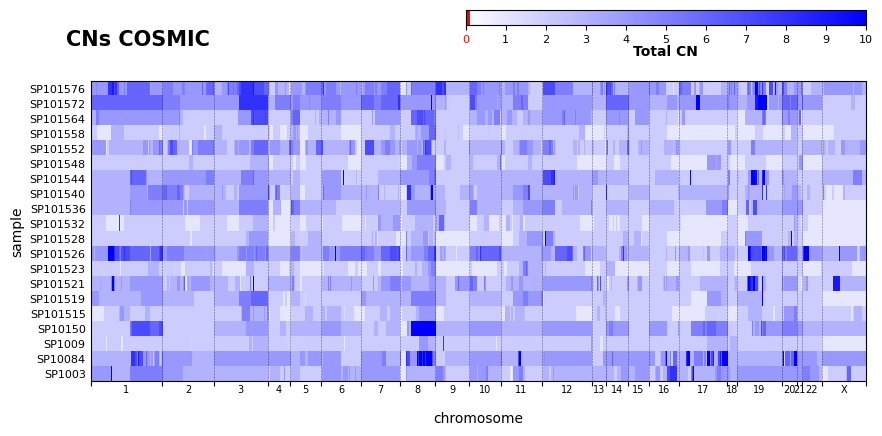

In [17]:
fig_CN_heatmap(cosmic_bins, "CNs COSMIC", dpi=100);

In [18]:
# join grouped and genes on chrom, start, end
grouped = grouped.reset_index()
merged = pd.merge(grouped, genes, on=["chrom", "start", "end"])
merged.head()

,index,cum_mid,chrom,start,end,major_cn,minor_cn,mid,length,total_cn,gene
0,0,2200846,chr1,2160134,2241558,1.800000,1.15,2200846,81424,2.950000,SKI
1,1,2491949,chr1,2487078,2496821,1.800000,1.15,2491949,9743,2.950000,TNFRSF14
2,2,3170458,chr1,2985732,3355185,1.800000,1.15,3170458,369453,2.950000,PRDM16
3,3,6255389,chr1,6241329,6269449,1.800000,1.10,6255389,28120,2.900000,RPL22
4,4,7337575,chr1,6845384,7829766,1.801263,1.15,7337575,984382,2.951263,CAMTA1


In [19]:
selection = merged.query("total_cn > 6")
selection

,index,cum_mid,chrom,start,end,major_cn,minor_cn,mid,length,total_cn,gene
317,317,1521546367,chr8,128747680,128753674,10.250000,1.600000,128750677,5994,11.850000,MYC
625,625,2689753332,chr19,30302805,30315215,6.378159,1.307329,30309010,12410,7.685488,CCNE1
626,626,2692860721,chr19,33369902,33462897,7.700000,1.500000,33416399,92995,9.200000,CEP89
627,627,2693236477,chr19,33790840,33793470,8.000000,1.450000,33792155,2630,9.450000,CEBPA
629,629,2700208155,chr19,40736224,40791443,6.150000,0.950000,40763833,55219,7.100000,AKT2


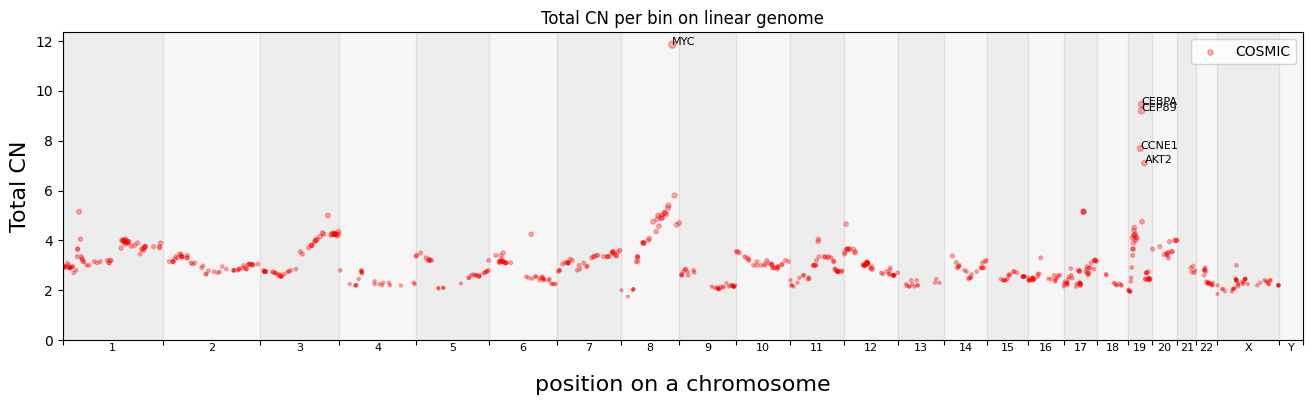

In [21]:

max_cn = merged["total_cn"].max() + .5

fig, ax = fig_manhattan(merged, "COSMIC", max_cn=max_cn)

# add text labels for selection["gene"]
for i, row in selection.iterrows():
    ax.text(row["cum_mid"], row["total_cn"], row["gene"], fontsize=8)